### 0. Import packages

In [ ]:
import logomaker
import glob as glob
import sys, os

os.path.dirname(sys.executable)

import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt

import sys, os, json, textwrap, itertools, requests
from pathlib import Path

from Bio.PDB import PDBParser, NeighborSearch, is_aa
from Bio.Data.IUPACData import protein_letters_3to1

import re
from typing import Optional          

from Bio.PDB import PDBParser, NeighborSearch
from scipy.spatial.distance import cdist



### 1. Exploration of structure-dervied peptides

In [ ]:
def aggregate_results(results_files, run_id_level=-2, extra_columns=None):
    """
    Aggregate CSV files into a single DataFrame with run identifiers.
    
    Args:
        results_files (list): List of paths to CSV files.
        run_id_level (int): Directory level to extract run ID (e.g., -2 for parent of filename).
        extra_columns (dict): Optional dictionary of column_name: lambda_function to add metadata.
    
    Returns:
        pd.DataFrame: Concatenated DataFrame with run IDs and optional columns.
    """
    if not results_files:
        print("Warning: No files provided.")
        return pd.DataFrame()

    dfs = []
    for file_path in results_files:
        # try:
        # Read CSV
        tmp = pd.read_csv(file_path)
        
        # Extract run ID from path
        run_id = os.path.split(os.path.dirname(file_path))[run_id_level]
        tmp['RUN'] = run_id
        
        # Add optional columns
        # if extra_columns:
        #     for col_name, func in extra_columns.items():
        #         tmp[col_name] = func(file_path)
        
        dfs.append(tmp)
        # print(f"Processed: {file_path}")

    # Concatenate all DataFrames
    if dfs:
        results = pd.concat(dfs, axis=0 )# , ignore_index=True)
        print(f"Aggregated {len(dfs)} files into DataFrame with {len(results)} rows.")
        return results
    else:
        print("No valid files processed.")
        return pd.DataFrame()

def grab_hla(title: str) -> Optional[str]:   # <- use Optional[str] instead of str | None
    """
    Return the first HLA allele in *title* or None.
    Handles:  HLA-A*02:01,  HLA-A02:01,  HLA-A*0201,  HLA-A0201
    """
    patterns = [
        r'(HLA-[A-Z]\*\d{2}:\d{2})',   # HLA-A*02:01
        r'(HLA-[A-Z]\d{2}:\d{2})',     # HLA-A02:01
        r'([A-Z]\*\d{4})',         # HLA-A*0201
        r'(-[A-Z]\*\d{2}:\d{2})'  ,
        r'([A-Z]\d{2}\d{2})'  ,
        r'([A-Z]\*\d{2}:\d{2})' ,
        r'(-[A-Z]\d{1}:\d{2})'  ,
        r'(-[A-Z]\d{1})'   ,
        r'(-[A-Z]\d{2})'            # HLA-A0201
    ]
    for p in patterns:
        m = re.search(p, title, flags=re.IGNORECASE)
        if m:
            return m.group(1).upper()
    return None

# Example usage for RFdiffusion results
# results_dir = "/clusterfs/nilah/sergio/RFdifussion/outputs/EPITOPE_SERIES_20250416/*/af2.csv"
# results_files = glob.glob('/clusterfs/nilah/sergio/RFdifussion/7RTD/*/*.csv')

# # Define extra columns (e.g., extract contigs, iterations, num_seqs from run name)
# extra_columns = {
#     'contigs': lambda x: x.split('/')[-3].split('_C')[1].split('_I')[0],
#     'iterations': lambda x: x.split('_I')[1].split('_NS')[0],
#     'num_seqs': lambda x: x.split('_NS')[1].split('_')[0]
# }

# # Aggregate results
# results = aggregate_results(results_files, run_id_level=-2) #, extra_columns=extra_columns)

results = pd.read_csv('../data/HLAA0201_PDB_7RTD_RFdiffusion_sequences.csv')
results['epitope'] = results['seq'].apply(lambda x: x.split("/")[1])
results['length'] = results['epitope'].apply(lambda x: len(x))
results = results.drop_duplicates('epitope')

<Axes: >

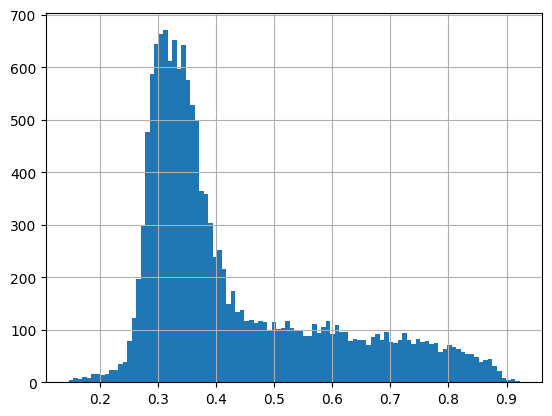

In [ ]:
results['plddt'].hist(bins=100)

In [ ]:
# results_meta = pd.merge(results_pdbs, df_meta, left_on='PDB', right_on='pdb_id', how='left')

results_meta = pd.read_csv('../data/rdfiffusion_output_peptides.csv.gz',compression='gzip')

results_meta['hla_allele'] = results_meta['title'].apply(grab_hla)
results_meta['hla_allele'] = results_meta['hla_allele'].str.replace('HLA','').str.replace('-','').str.replace(':','').str.replace('*','')
results_meta['epitope'] = results_meta['seq'].apply(lambda x: x.split("/")[1])
results_meta['length'] = results_meta['epitope'].apply(lambda x: len(x))
results_meta = results_meta.drop_duplicates(['pdb_id', 'epitope'])

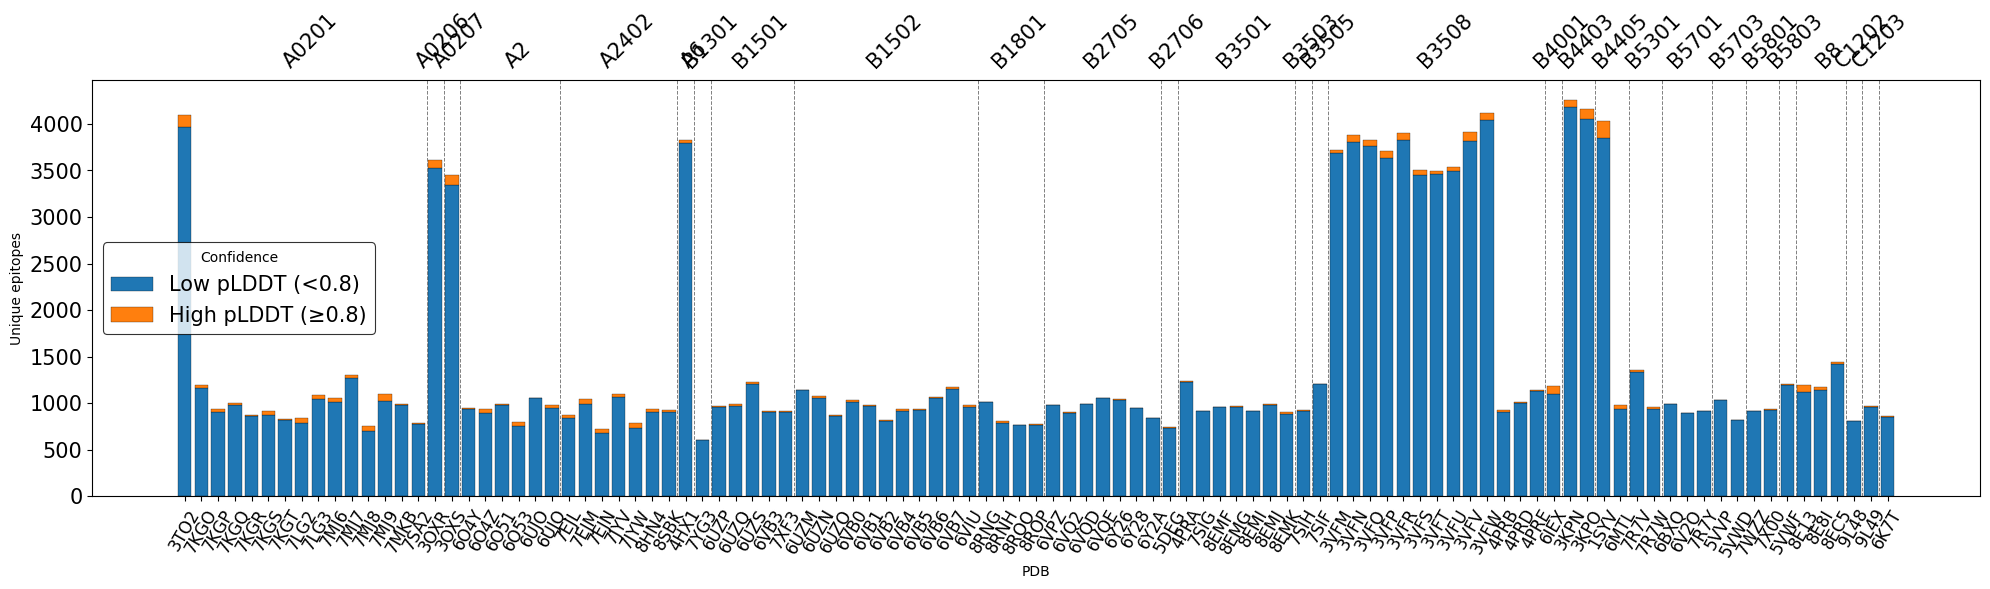

In [ ]:

# ------------------------------------------------------------------
# 1.  Build a long table with a confidence label
# ------------------------------------------------------------------
tmp = (
    results_meta
      .drop_duplicates(subset=['epitope', 'PDB'])           # one epitope / PDB
      .assign(conf=lambda d: np.where(d['plddt'] >= 0.8,
                                      'High pLDDT (≥0.8)',
                                      'Low pLDDT (<0.8)'))
)

counts = (tmp
          .groupby(['hla_allele', 'PDB', 'conf'])
          .size()
          .reset_index(name='num_epitopes'))

# ------------------------------------------------------------------
# 2.  Order bars: hla_allele blocks, then TOTAL-count desc. within each block
# ------------------------------------------------------------------
# 2-a. get total per PDB to sort inside each allele block
total = (counts.groupby(['hla_allele', 'PDB'])['num_epitopes']
               .sum()
               .reset_index(name='total_epitopes'))

counts = counts.merge(total, on=['hla_allele', 'PDB'])

counts = (counts
          .sort_values(['hla_allele', 'total_epitopes'],
                       ascending=[True, False])
          .reset_index(drop=True))

# track allele boundaries
allele_boundary = counts[['hla_allele', 'PDB']].drop_duplicates()
allele_boundary['group_idx'] = allele_boundary['hla_allele'].ne(
                                   allele_boundary['hla_allele'].shift()
                               ).cumsum()
counts = counts.merge(allele_boundary, on=['hla_allele', 'PDB'])

bar_order = allele_boundary['PDB'].tolist()        # order for plotting

# ------------------------------------------------------------------
# 3.  Pivot to wide form for a manual stacked plot
# ------------------------------------------------------------------
wide = (counts
        .pivot_table(index=['hla_allele', 'PDB', 'group_idx'],
                     columns='conf',
                     values='num_epitopes',
                     fill_value=0)
        .reset_index())

# guarantee both columns exist even if one tier is missing
for c in ['High pLDDT (≥0.8)', 'Low pLDDT (<0.8)']:
    if c not in wide.columns:
        wide[c] = 0

# ------------------------------------------------------------------
# 4.  Draw stacked bars
# ------------------------------------------------------------------
plt.figure(figsize=(20, 6))

bottom = np.zeros(len(wide))
colors = ['tab:blue', 'tab:orange']   # low first (bottom), high on top
labels = ['Low pLDDT (<0.8)', 'High pLDDT (≥0.8)']

for col, color, lab in zip(labels, colors, labels):
    plt.bar(
        x=wide['PDB'],
        height=wide[col],
        bottom=bottom,
        color=color,
        label=lab,
        edgecolor='black',
        linewidth=0.2
    )
    bottom += wide[col].values

plt.xticks(rotation=60, fontsize=12)
plt.yticks(fontsize=15)
plt.ylabel('Unique epitopes')
plt.xlabel('PDB')

plt.legend(
    title='Confidence',
    frameon=True,              # draw a legend box
    fontsize=15
)

# give that box a white fill and a thin black border
leg = plt.gca().get_legend()
leg.get_frame().set_facecolor('white')   # white background
leg.get_frame().set_edgecolor('black')   # optional: black outline
leg.get_frame().set_linewidth(0.8)


# ------------------------------------------------------------------
# 5.  Add vertical separators + allele labels
# ------------------------------------------------------------------
group_sizes = wide.groupby('group_idx').size().cumsum().values[:-1]

for xc in group_sizes:
    plt.axvline(x=xc - 0.5, color='grey', linestyle='--', lw=0.7)

midpoints = np.insert(group_sizes, 0, 0)
midpoints = (midpoints[:-1] + group_sizes) / 2
for xmid, allele in zip(midpoints, wide['hla_allele'].unique()):
    plt.text(xmid, plt.ylim()[1] * 1.02, allele,
             ha='center', va='bottom', fontsize=15, rotation=45)
             
plt.tight_layout()
plt.show()


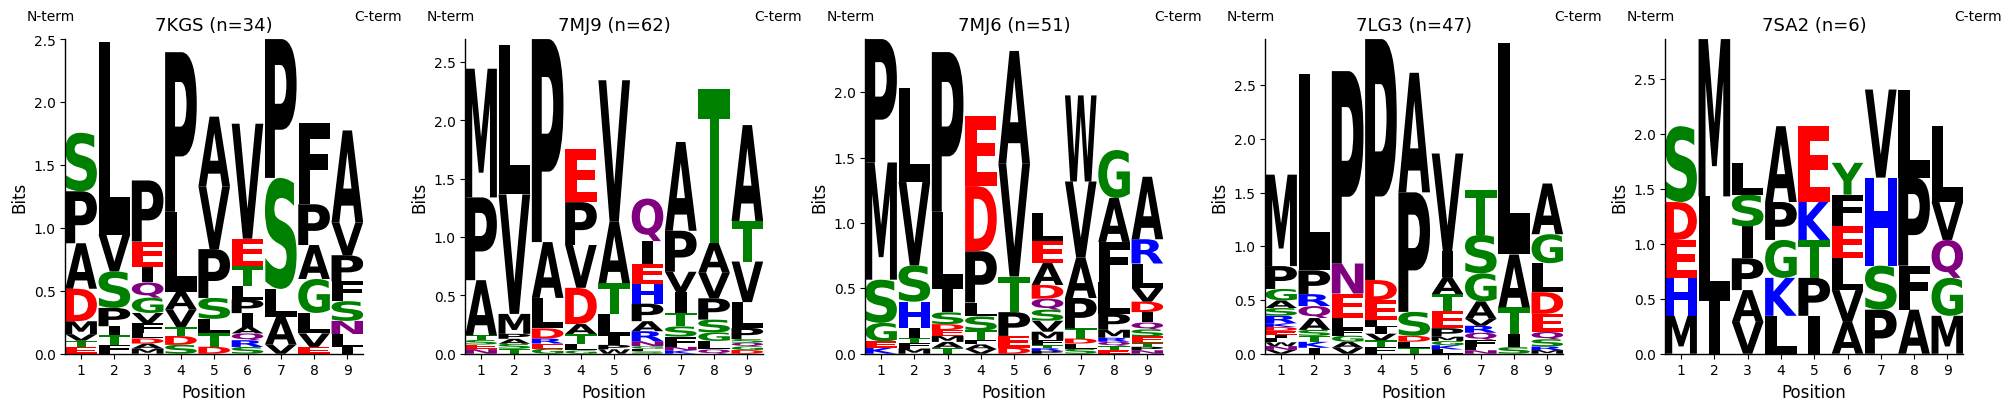

In [ ]:
allele      = 'A0201'
pdbs        = ['7KGS', '7MJ9', '7MJ6', '7LG3', '7SA2'] #['7KGS', '7MJ9', '7MJ6', '7LG3', '7SA2'] # ['6UZS', '6VB3', '6UZQ', '7XF3'] #results_meta[results_meta['hla_allele'] == allele]['PDB'].unique() #['6UZS', '7XF3', '6VB3', '6UZQ'] #['7KGS', '7MJ9', '7MJ6', '7LG3', '7SA2'] #results_meta[results_meta['hla_allele'] == allele]['PDB'].unique()[7:] 
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
n = 9   # only 9-mers

fig, axes = plt.subplots(1, len(pdbs), figsize=(20, 4), constrained_layout=True)
found = False

for ax, pdb in zip(axes, pdbs):
    mask = (
        (results_meta['PDB'] == pdb) &
        (results_meta['epitope'].str.len() == n) &
        (results_meta['plddt'] >= 0.7)
    )
    entries = results_meta.loc[mask, 'epitope'].drop_duplicates()
    seqs    = entries.tolist()
    
    if not seqs:
        ax.axis('off')
        ax.set_title(f"{pdb}\n(no {n}-mers)", fontsize=12)
        continue

    found = True
    # count matrix
    count_mat = np.zeros((n, len(amino_acids)), dtype=float)
    for seq in seqs:
        for pos, aa in enumerate(seq):
            try:
                idx = amino_acids.index(aa)
            except ValueError:
                continue
            count_mat[pos, idx] += 1

    # frequencies
    freq_mat = count_mat / count_mat.sum(axis=1, keepdims=True)
    freq_df  = pd.DataFrame(freq_mat, columns=amino_acids)

    # uniform background array
    bg_array = [1/20] * len(amino_acids)

    # information content
    info_df = logomaker.transform_matrix(
        freq_df,
        from_type='probability',
        to_type='information',
        background=bg_array
    )

    # draw the logo
    logo = logomaker.Logo(
        info_df,
        ax=ax,
        color_scheme='chemistry',
    )
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left','bottom'], visible=True)

    # X ticks and labels
    ax.set_xticks(range(n))
    ax.set_xticklabels([str(i+1) for i in range(n)])
    ax.set_xlabel("Position", fontsize=12)
    ax.set_ylabel("Bits", fontsize=12)

    # annotate N- and C-termini
    ax.text(
        -0.2, 1.05, "N-term",
        transform=ax.get_xaxis_transform(),
        ha='right', va='bottom', fontsize=10
    )
    ax.text(
        n-0.8, 1.05, "C-term",
        transform=ax.get_xaxis_transform(),
        ha='left', va='bottom', fontsize=10
    )

    # only PDB + peptide count in title
    ax.set_title(f"{pdb} (n={len(seqs)})", fontsize=13)
    
plt.show()



In [ ]:
AA = list("ACDEFGHIKLMNPQRSTVWY")
def build_pwm(df: pd.DataFrame,
              seq_col: str,
              allele_col: str,
              length: int = 9,
              pseudocount: int = 1):
    """
    Return {allele: (L, 20) numpy array} where rows = positions,
    columns = AA probabilities.
    Only sequences of exact 'length' are used.
    """
    pwm = {}
    for hla, grp in df[df[seq_col].str.len() == length].groupby(allele_col):
        counts = np.zeros((length, 20))
        for seq in grp[seq_col]:
            for i, aa in enumerate(seq):
                if aa in AA:
                    counts[i, AA.index(aa)] += 1
        counts += pseudocount
        pwm[hla] = counts / counts.sum(axis=1, keepdims=True)
    return pwm

In [ ]:
# results.to_csv('untargetted_anchoring_RFD.csv', index=False)
results = pd.read_csv('../data/untargetted_anchoring_RFD.csv.gz', compression='gzip')
results['pdb_id'] = results['RUN'].str.split('/',expand= True)[6]
results = pd.merge(
    results,
    results_meta[['hla_allele','pdb_id']].drop_duplicates(),
    on=['pdb_id'],
    how='left')
results['epitope'] = results['seq'].str.split('/', expand=True)[1]

In [ ]:
# http://mhcmotifatlas.org/class1